In [1]:
# Подключение Python к базе, импорт необходимых библиотек

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

conn = sqlite3.connect(r'C:\Users\anast\OneDrive\Desktop\project\bike_project')

orders = pd.read_sql('SELECT * FROM orders', conn)
order_items = pd.read_sql('SELECT * FROM order_items', conn)
products = pd.read_sql('SELECT * FROM products', conn)
customers = pd.read_sql('SELECT * FROM customers', conn)
stores = pd.read_sql('SELECT * FROM stores', conn)
categories = pd.read_sql('SELECT * FROM categories', conn)
brands = pd.read_sql('SELECT * FROM brands', conn)

pd.options.display.float_format = '{:,.2f}'.format

In [2]:
# Определение когорты каждого клиента (в зависимости от месяца первой покупки)

first_purchase = orders.groupby('customer_id')['order_date'].min().reset_index()
first_purchase.columns = ['customer_id', 'first_purchase_date']

orders = orders.merge(first_purchase, on='customer_id')

In [4]:
# Определение периода жизни клиента

orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['first_purchase_date'] = pd.to_datetime(orders['first_purchase_date'])

orders['order_period'] = orders['order_date'].dt.to_period('M')
orders['cohort_period'] = orders['first_purchase_date'].dt.to_period('M')

def period_diff(row):
    return (
        (row['order_period'].year - row['cohort_period'].year) * 12
        + (row['order_period'].month - row['cohort_period'].month)
    )

orders['cohort_index'] = orders.apply(period_diff, axis=1)

In [11]:
# Подсчет размера когорт, построение сводной таблицы

cohort_data = (
    orders.groupby(['cohort_period', 'cohort_index'])['customer_id']
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_data.pivot_table(
    index='cohort_period',
    columns='cohort_index',
    values='customer_id'
)

print(cohort_pivot.iloc[:10, :6]) # вывод первых 10 строк и первых 6 столбцов для удобства

cohort_index      0    1    2    3    4    5
cohort_period                               
2016-01       50.00  NaN  NaN  NaN  NaN  NaN
2016-02       49.00  NaN  NaN  NaN  NaN  NaN
2016-03       55.00  NaN  NaN  NaN  NaN  NaN
2016-04       42.00  NaN  NaN  NaN 1.00  NaN
2016-05       51.00  NaN 1.00  NaN  NaN  NaN
2016-06       45.00  NaN  NaN  NaN  NaN 1.00
2016-07       49.00  NaN  NaN  NaN  NaN  NaN
2016-08       62.00 2.00  NaN 1.00  NaN  NaN
2016-09       64.00  NaN  NaN  NaN  NaN  NaN
2016-10       64.00  NaN  NaN  NaN  NaN  NaN


In [12]:
# Расчет retention rate (перевод абсолютных значений в проценты)

cohort_sizes = cohort_pivot.iloc[:, 0]  # столбец с cohort_index = 0 — размер когорты целиком
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100

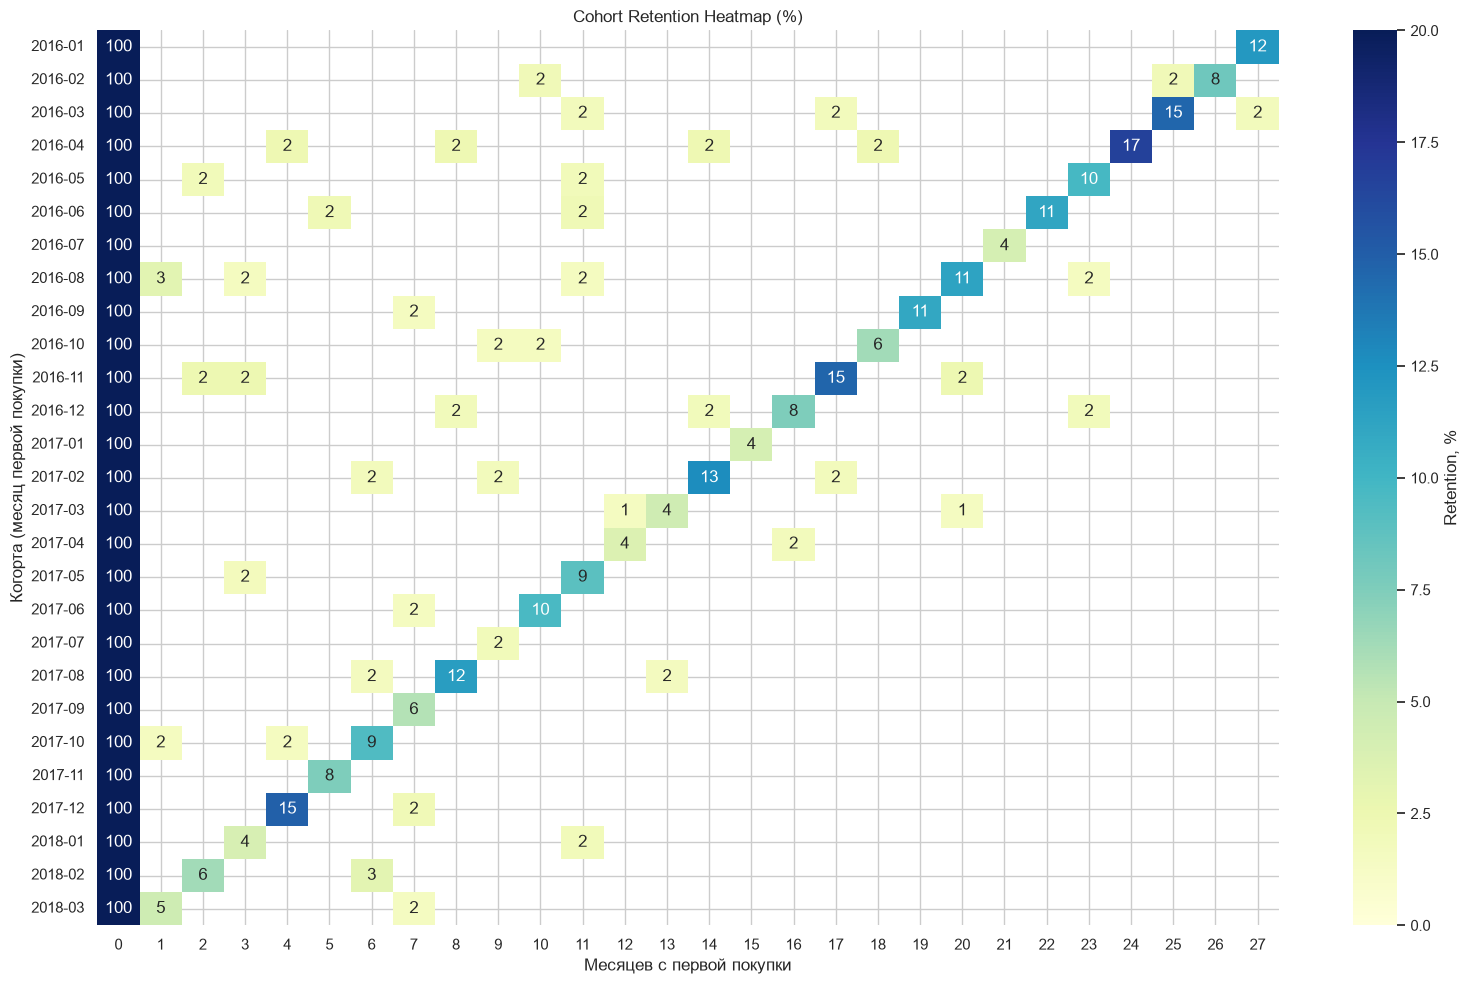

In [13]:
# Визуализация

plt.figure(figsize=(16, 10))
sns.heatmap(
    retention,
    annot=True, fmt='.0f',
    cmap='YlGnBu',
    vmin=0, vmax=20,  # ограничиваем шкалу цвета: retention всё равно низкий
    cbar_kws={'label': 'Retention, %'}
)
plt.title('Cohort Retention Heatmap (%)')
plt.xlabel('Месяцев с первой покупки')
plt.ylabel('Когорта (месяц первой покупки)')
plt.tight_layout()
plt.show()

Примечание

- По вертикальной оси — когорты (месяц первой покупки клиента), по горизонтальной оси — количество месяцев, которое прошло с момента этой покупки. Значение в ячейке — % клиентов когорты, вернувшихся именно в этот месяц
- Высокое значение в первом столбце (100%) связано с тем, что это момент формирования соответствующей когорты
- Пустой треугольник справа внизу указывает на нехватку времени: у поздних когорт (конец 2018) ещё не прошло достаточно месяцев, чтобы там могли появиться значения
- Остальные пустые ячейки означают, что никто из когорты не вернулся в этот месяц — таких ячеек на графике большинство
- Заполненные ячейки — единичные проценты (1-4%), закономерностей по месяцам не прослеживается

Retention низкий и "шумный", потому что 75% клиентов совершают только одну покупку за весь период наблюдений — это является спецификой
категории (велосипед покупают редко — после покупки велосипед обычно служит продолжительное время). Для более содержательных выводов лучше подходит агрегированная метрика "вернулся ли клиент хотя бы раз" (совершил ли хотя бы один повторный заказ), см. ниже

               cohort_size  returned_customers  return_rate_%
cohort_period                                                
2016-01                 50                   6          12.00
2016-02                 49                   4           8.20
2016-03                 55                   8          14.50
2016-04                 42                   7          16.70
2016-05                 51                   5           9.80
2016-06                 45                   5          11.10
2016-07                 49                   2           4.10
2016-08                 62                   7          11.30
2016-09                 64                   8          12.50
2016-10                 64                   4           6.20
2016-11                 41                   6          14.60
2016-12                 53                   4           7.50
2017-01                 49                   2           4.10
2017-02                 55                   8          14.50
2017-03 

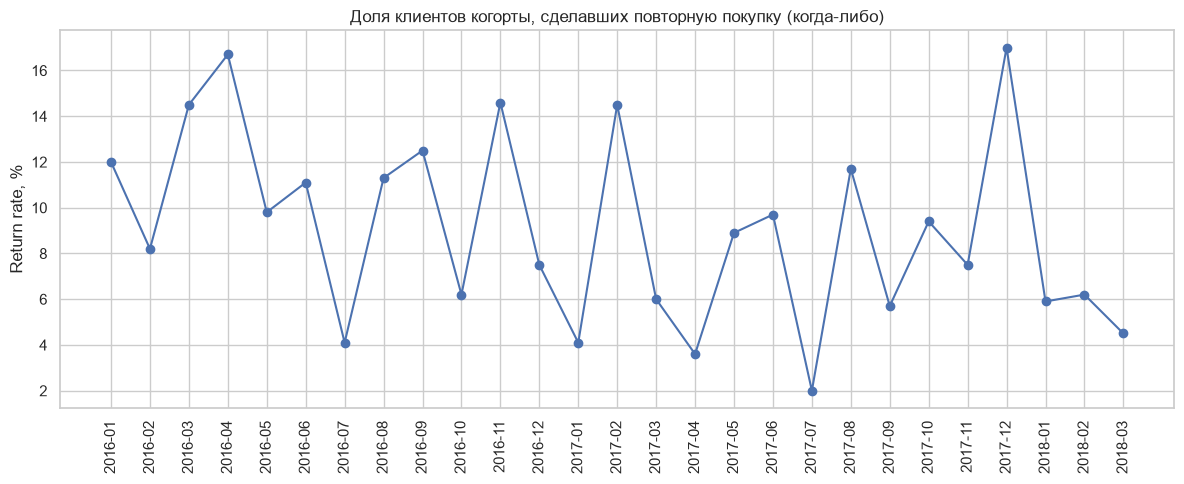

In [9]:
# Расчет возвращаемости клиентов (сколько клиентов совершили хотя бы одну повторную покупку)

ever_returned = (
    orders.groupby('cohort_period')['customer_id']
    .nunique()
    .rename('cohort_size')
    .to_frame()
)

repeat_customers = (
    orders[orders['cohort_index'] > 0]
    .groupby('cohort_period')['customer_id']
    .nunique()
    .rename('returned_customers')
)

ever_returned = ever_returned.join(repeat_customers).fillna(0)
ever_returned['return_rate_%'] = (
    ever_returned['returned_customers'] / ever_returned['cohort_size'] * 100
).round(1)

print(ever_returned)

# Визуализация

plt.figure(figsize=(12, 5))
plt.plot(ever_returned.index.astype(str), ever_returned['return_rate_%'], marker='o')
plt.xticks(rotation=90)
plt.title('Доля клиентов когорты, сделавших повторную покупку (когда-либо)')
plt.ylabel('Return rate, %')
plt.tight_layout()
plt.show()

In [14]:
# Расчет среднего процента возвращающихся клиентов по когортам

mean_return_rate = ever_returned['return_rate_%'].mean()
print(f'Средний return rate по когортам: {mean_return_rate:.1f}%')

Средний return rate по когортам: 9.1%


В среднем по когортам возвращается ~9% клиентов, с большим разбросом между когортами (от 2% до 17%) без выраженного сезонного паттерна. Заметен плавный спад по годам — 10.7% в 2016 → 8.3% в 2017 → 5.5% в 2018, но это ожидаемо: у более поздних когорт объективно было меньше времени, чтобы проявить повторную покупку, поэтому сравнивать их напрямую с ранними некорректно.

Основные выводы и наблюдения

- Классическая помесячная cohort retention heatmap для этого датасета получается разреженной: 75% клиентов совершают только одну покупку за всё время наблюдения — это ожидаемо для категории товара с длинным циклом повторной покупки (велосипед не покупают каждый месяц), а не сигнал о проблеме удержания
- Более показательная метрика для этой категории — "return rate" (вернулся ли клиент хоть раз, без привязки к месяцу): в среднем по когортам возвращается 9.1% клиентов
- Ранние когорты (2016 год) имеют больше времени для возникновения необходимости повторной покупки относительно поздних когорт (2018 год) — при сравнении когорт между собой это необходимо учитывать, иначе расчеты показател